--- PARÂMETROS TEÓRICOS ---
Ocupação Esperada (Rho): 50.0%
Tempo de Espera na Fila Esperado (Wq): 0.5 min



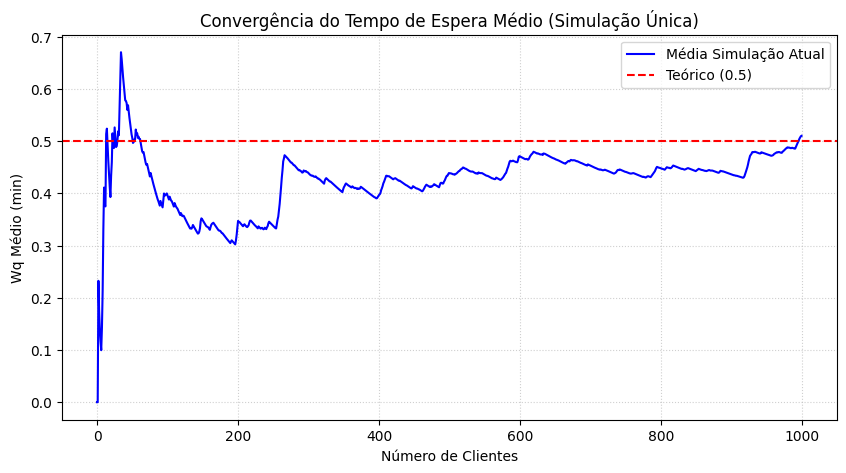

--- RESULTADO DA SIMULAÇÃO ---
Ocupação Observada (Rho): 0.4821
Tempo de Espera Médio (Wq): 0.5101 min


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

lambda_rate = 1.0
mu_rate = 2.0
n_clientes = 1000
n_simulacoes = 1

rho_teorico = lambda_rate / mu_rate
wq_teorico = rho_teorico / (mu_rate - lambda_rate)

print(f"--- PARÂMETROS TEÓRICOS ---")
print(f"Ocupação Esperada (Rho): {rho_teorico*100}%")
print(f"Tempo de Espera na Fila Esperado (Wq): {wq_teorico} min\n")

tec = np.random.exponential(1/lambda_rate, n_clientes)
ts = np.random.exponential(1/mu_rate, n_clientes)

instante_chegada = np.cumsum(tec)
inicio_servico = np.zeros(n_clientes)
fim_servico = np.zeros(n_clientes)
espera_fila = np.zeros(n_clientes)

for j in range(n_clientes):
    if j == 0:
        inicio_servico[j] = instante_chegada[j]
    else:
        inicio_servico[j] = max(instante_chegada[j], fim_servico[j-1])

    espera_fila[j] = inicio_servico[j] - instante_chegada[j]
    fim_servico[j] = inicio_servico[j] + ts[j]

tempo_total_sim = fim_servico[-1]
rho_simulado = np.sum(ts) / tempo_total_sim
wq_medio_simulado = np.mean(espera_fila)

plt.figure(figsize=(10, 5))
media_movel_wq = np.cumsum(espera_fila) / (np.arange(n_clientes) + 1)

plt.plot(media_movel_wq, color='blue', label='Média Simulação Atual')
plt.axhline(y=wq_teorico, color='red', linestyle='--', label=f'Teórico ({wq_teorico})')

plt.title('Convergência do Tempo de Espera Médio (Simulação Única)')
plt.xlabel('Número de Clientes')
plt.ylabel('Wq Médio (min)')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

print("--- RESULTADO DA SIMULAÇÃO ---")
print(f"Ocupação Observada (Rho): {rho_simulado:.4f}")
print(f"Tempo de Espera Médio (Wq): {wq_medio_simulado:.4f} min")